# Naive Bayes Manual — Prediksi Obat (Dataset Drug200)

Notebook ini membangun model **Naive Bayes untuk data kategorik dari nol**
(Prior & Likelihood dihitung manual, **tanpa scikit-learn**), dibantu **pandas**
& **numpy** untuk pengolahan data, dan **seaborn** untuk visualisasi.

**Struktur folder:**
```
project/
├── data/
│   └── drug200(NAIVE BAYES).xlsx
└── main.ipynb   <- file ini
```

**Daftar isi notebook:**
1. Setup Library
2. Load Data + Tabel (5 data teratas) + Info Jumlah Data
3. Sebaran Data Tiap Fitur terhadap Jenis Obat
4. Hitung Prior P(Drug) — tanpa keterlibatan fitur lain
5. Prior x Likelihood(Age)
6. Prior x Likelihood(BP)
7. Prior x Likelihood(Cholesterol)
8. Prior x Likelihood(Na_to_K)
9. Input Data Uji (Kasus Pasien Baru)
10. Hasil Prediksi Akhir (Posterior Gabungan Semua Fitur)
11. Kesimpulan — Fitur Paling Berpengaruh


## 1. Setup Library
Hanya **pandas** & **numpy** untuk pengolahan data, **matplotlib** & **seaborn** untuk
visualisasi. **Tidak ada scikit-learn** — semua rumus Naive Bayes ditulis manual.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 2. Load Data + Tabel (5 Data Teratas) + Info Jumlah Data

In [3]:
DATA_PATH = "data/drug200(NAIVE BAYES).xlsx"

df = pd.read_excel(DATA_PATH, sheet_name="drug200")

nama_kolom = [k for k in df.columns if k != "ClassDrug"]   # nama fitur
kolom_label = "ClassDrug"

print("5 Data Teratas:")
df.head()

5 Data Teratas:


,Age,BP,Cholesterol,Na_to_K,ClassDrug
0,YOUNG,HIGH,HIGH,NORMAL,drugA
1,YOUNG,HIGH,HIGH,NORMAL,drugA
2,YOUNG,HIGH,HIGH,LOW,drugA
3,YOUNG,HIGH,NORMAL,LOW,drugA
4,ADULT,HIGH,NORMAL,NORMAL,drugA


In [4]:
print(f"Total data keseluruhan : {df.shape[0]} baris")
print(f"Total fitur            : {len(nama_kolom)} -> {nama_kolom}")
print(f"Total kelas obat        : {df[kolom_label].nunique()} -> {sorted(df[kolom_label].unique())}")
print()

print("Jumlah data per fitur (kategori unik & jumlah masing-masing):")
for kolom in nama_kolom:
    print(f"\n-- {kolom} --")
    print(df[kolom].value_counts())

Total data keseluruhan : 200 baris
Total fitur            : 4 -> ['Age', 'BP', 'Cholesterol', 'Na_to_K']
Total kelas obat        : 5 -> ['DrugY', 'drugA', 'drugB', 'drugC', 'drugX']

Jumlah data per fitur (kategori unik & jumlah masing-masing):

-- Age --
Age
OLD      101
ADULT     66
YOUNG     33
Name: count, dtype: int64

-- BP --
BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64

-- Cholesterol --
Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64

-- Na_to_K --
Na_to_K
NORMAL    106
HIGH       62
LOW        32
Name: count, dtype: int64


## 3. Sebaran Data Berdasarkan Fitur dengan Jenis Obat
Melihat bagaimana tiap fitur (Age, BP, Cholesterol, Na_to_K) berhubungan dengan
jenis obat yang diberikan.

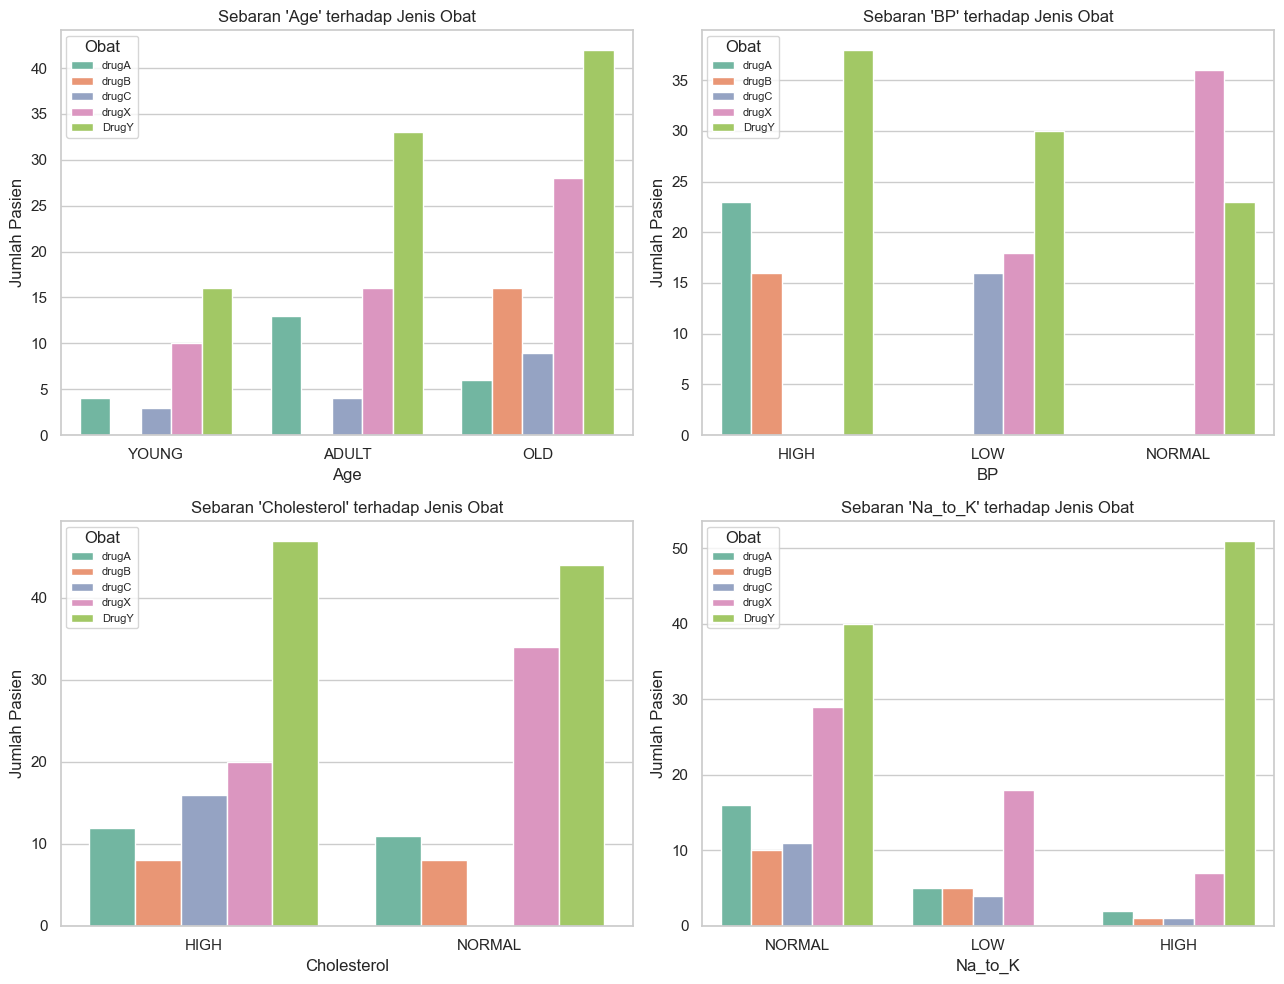

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, kolom in enumerate(nama_kolom):
    sns.countplot(data=df, x=kolom, hue=kolom_label, palette="Set2", ax=axes[i])
    axes[i].set_title(f"Sebaran '{kolom}' terhadap Jenis Obat")
    axes[i].set_xlabel(kolom)
    axes[i].set_ylabel("Jumlah Pasien")
    axes[i].legend(title="Obat", fontsize=8)

plt.tight_layout()
plt.show()

## 4. Hitung Prior P(Drug) — Tanpa Keterlibatan Fitur Lain
Prior murni dihitung dari proporsi jumlah tiap kelas obat terhadap total data,
**belum melibatkan fitur apapun**:

$$P(Drug = k) = \dfrac{\text{jumlah pasien berkelas } k}{\text{total pasien}}$$

In [6]:
jumlah_per_kelas = df.groupby(kolom_label).size()
total_data = len(df)

prior = jumlah_per_kelas / total_data

tabel_prior = pd.DataFrame({"Jumlah": jumlah_per_kelas, "Prior": prior})
tabel_prior

,Jumlah,Prior
ClassDrug,,
DrugY,91,0.4550
drugA,23,0.1150
drugB,16,0.0800
drugC,16,0.0800
drugX,54,0.2700


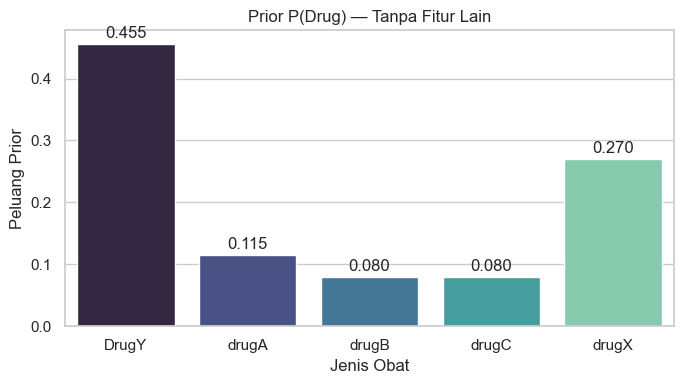

In [7]:
plt.figure(figsize=(7, 4))
sns.barplot(x=prior.index, y=prior.values, hue=prior.index, palette="mako", legend=False)
plt.title("Prior P(Drug) — Tanpa Fitur Lain")
plt.xlabel("Jenis Obat")
plt.ylabel("Peluang Prior")
for i, v in enumerate(prior.values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

### Fungsi Bantuan
Sebelum masuk ke bagian 5–8, disiapkan dua fungsi kecil yang akan dipakai berulang:
- `hitung_likelihood_fitur()` -> menghitung tabel likelihood satu fitur terhadap kelas
- `uji_satu_fitur()` -> menguji seberapa akurat model **jika hanya mengandalkan satu fitur** (Prior x Likelihood fitur itu saja), untuk melihat seberapa kuat pengaruh fitur tersebut sendirian.

In [8]:
def hitung_likelihood_fitur(df, kolom_fitur, kolom_label):
    """Rumus manual: P(fitur=v | kelas) = jumlah(kelas,fitur=v) / jumlah(kelas)"""
    tabel_kontingensi = pd.crosstab(df[kolom_label], df[kolom_fitur])
    tabel_likelihood = tabel_kontingensi.div(tabel_kontingensi.sum(axis=1), axis=0)
    return tabel_likelihood


def uji_satu_fitur(df, kolom_fitur, kolom_label, prior, likelihood_fitur):
    """Prediksi tiap baris HANYA memakai Prior x Likelihood(fitur ini),
    lalu bandingkan dengan label asli -> hasilnya berupa akurasi (%)."""
    daftar_kelas = prior.index.to_numpy()
    benar = 0

    for _, baris in df.iterrows():
        nilai = baris[kolom_fitur]
        if nilai in likelihood_fitur.columns:
            peluang = likelihood_fitur[nilai].reindex(daftar_kelas).to_numpy(dtype=float)
        else:
            peluang = np.zeros(len(daftar_kelas))

        skor = prior.to_numpy(dtype=float) * peluang
        kelas_tebakan = daftar_kelas[np.argmax(skor)]

        if kelas_tebakan == baris[kolom_label]:
            benar += 1

    return benar / len(df) * 100

## 5. Hitung Likelihood + Prior Drug dengan Age
Rumus: $P(Drug=k \mid Age=v) \propto P(Drug=k) \times P(Age=v \mid Drug=k)$

(Ini baru memakai **satu fitur** — Age saja — belum digabung dengan fitur lain.)

In [9]:
likelihood_age = hitung_likelihood_fitur(df, "Age", kolom_label)
print("Likelihood P(Age | Drug):")
likelihood_age

Likelihood P(Age | Drug):


Age,ADULT,OLD,YOUNG
ClassDrug,,,
DrugY,0.3626,0.4615,0.1758
drugA,0.5652,0.2609,0.1739
drugB,0.0000,1.0000,0.0000
drugC,0.2500,0.5625,0.1875
drugX,0.2963,0.5185,0.1852


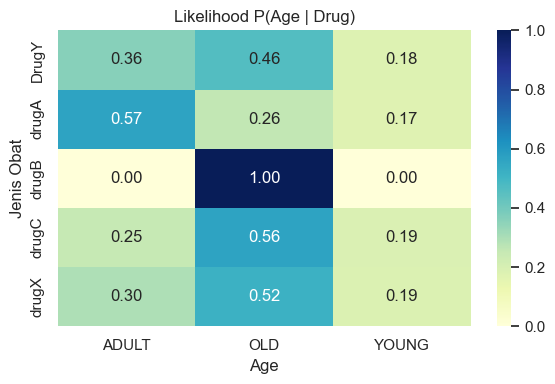

Akurasi model jika HANYA memakai fitur Age: 45.50%


In [10]:
plt.figure(figsize=(6, 4))
sns.heatmap(likelihood_age, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Likelihood P(Age | Drug)")
plt.xlabel("Age")
plt.ylabel("Jenis Obat")
plt.tight_layout()
plt.show()

akurasi_age = uji_satu_fitur(df, "Age", kolom_label, prior, likelihood_age)
print(f"Akurasi model jika HANYA memakai fitur Age: {akurasi_age:.2f}%")

## 6. Hitung Likelihood + Prior Drug dengan BP
Rumus: $P(Drug=k \mid BP=v) \propto P(Drug=k) \times P(BP=v \mid Drug=k)$

In [11]:
likelihood_bp = hitung_likelihood_fitur(df, "BP", kolom_label)
print("Likelihood P(BP | Drug):")
likelihood_bp

Likelihood P(BP | Drug):


BP,HIGH,LOW,NORMAL
ClassDrug,,,
DrugY,0.4176,0.3297,0.2527
drugA,1.0000,0.0000,0.0000
drugB,1.0000,0.0000,0.0000
drugC,0.0000,1.0000,0.0000
drugX,0.0000,0.3333,0.6667


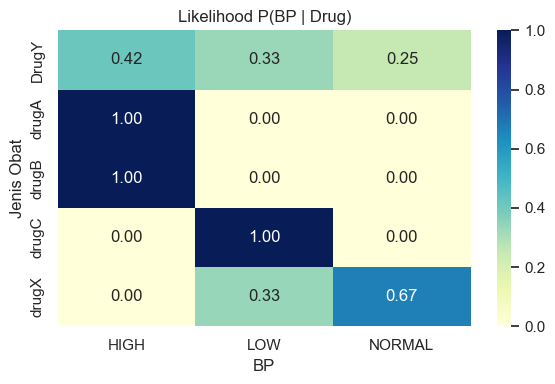

Akurasi model jika HANYA memakai fitur BP: 52.00%


In [12]:
plt.figure(figsize=(6, 4))
sns.heatmap(likelihood_bp, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Likelihood P(BP | Drug)")
plt.xlabel("BP")
plt.ylabel("Jenis Obat")
plt.tight_layout()
plt.show()

akurasi_bp = uji_satu_fitur(df, "BP", kolom_label, prior, likelihood_bp)
print(f"Akurasi model jika HANYA memakai fitur BP: {akurasi_bp:.2f}%")

## 7. Hitung Likelihood + Prior Drug dengan Cholesterol
Rumus: $P(Drug=k \mid Chol=v) \propto P(Drug=k) \times P(Chol=v \mid Drug=k)$

In [13]:
likelihood_chol = hitung_likelihood_fitur(df, "Cholesterol", kolom_label)
print("Likelihood P(Cholesterol | Drug):")
likelihood_chol

Likelihood P(Cholesterol | Drug):


Cholesterol,HIGH,NORMAL
ClassDrug,,
DrugY,0.5165,0.4835
drugA,0.5217,0.4783
drugB,0.5000,0.5000
drugC,1.0000,0.0000
drugX,0.3704,0.6296


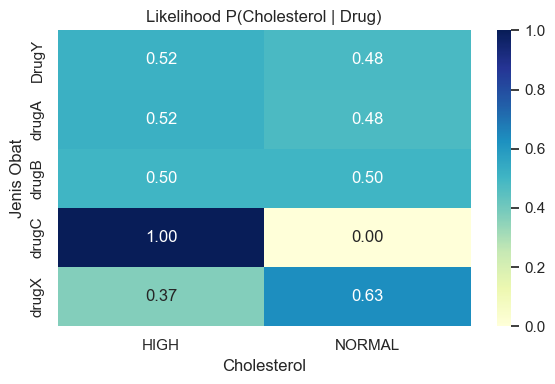

Akurasi model jika HANYA memakai fitur Cholesterol: 45.50%


In [14]:
plt.figure(figsize=(6, 4))
sns.heatmap(likelihood_chol, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Likelihood P(Cholesterol | Drug)")
plt.xlabel("Cholesterol")
plt.ylabel("Jenis Obat")
plt.tight_layout()
plt.show()

akurasi_chol = uji_satu_fitur(df, "Cholesterol", kolom_label, prior, likelihood_chol)
print(f"Akurasi model jika HANYA memakai fitur Cholesterol: {akurasi_chol:.2f}%")

## 8. Hitung Likelihood + Prior Drug dengan Na_to_K
Rumus: $P(Drug=k \mid Na\_to\_K=v) \propto P(Drug=k) \times P(Na\_to\_K=v \mid Drug=k)$

> Catatan: pada sheet Excel awal, `Na_to_K` sudah dikategorikan menjadi HIGH/LOW/NORMAL,
> jadi diperlakukan sama seperti fitur kategorik lainnya.

In [15]:
likelihood_natok = hitung_likelihood_fitur(df, "Na_to_K", kolom_label)
print("Likelihood P(Na_to_K | Drug):")
likelihood_natok

Likelihood P(Na_to_K | Drug):


Na_to_K,HIGH,LOW,NORMAL
ClassDrug,,,
DrugY,0.5604,0.0000,0.4396
drugA,0.0870,0.2174,0.6957
drugB,0.0625,0.3125,0.6250
drugC,0.0625,0.2500,0.6875
drugX,0.1296,0.3333,0.5370


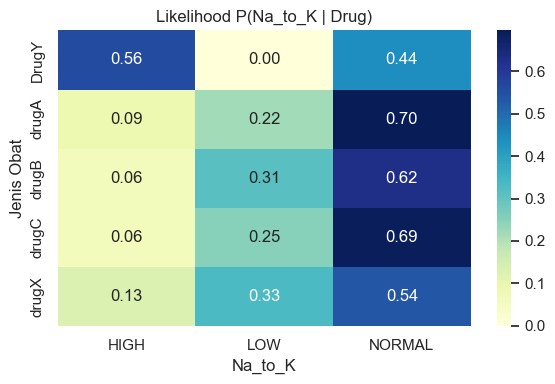

Akurasi model jika HANYA memakai fitur Na_to_K: 54.50%


In [16]:
plt.figure(figsize=(6, 4))
sns.heatmap(likelihood_natok, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Likelihood P(Na_to_K | Drug)")
plt.xlabel("Na_to_K")
plt.ylabel("Jenis Obat")
plt.tight_layout()
plt.show()

akurasi_natok = uji_satu_fitur(df, "Na_to_K", kolom_label, prior, likelihood_natok)
print(f"Akurasi model jika HANYA memakai fitur Na_to_K: {akurasi_natok:.2f}%")

## 9. Isi Data Uji (Kasus Pasien Baru)
Silakan ganti nilai di bawah ini untuk mencoba kasus pasien lain.
Default-nya memakai contoh yang sama seperti sheet Excel *Simulasi*.

In [17]:
pasien_baru = {
    "Age": "OLD",           # pilihan: YOUNG / ADULT / OLD
    "BP": "HIGH",           # pilihan: HIGH / LOW / NORMAL
    "Cholesterol": "NORMAL",  # pilihan: HIGH / NORMAL
    "Na_to_K": "HIGH",      # pilihan: HIGH / LOW / NORMAL
}

print("Data uji (pasien baru):")
for k, v in pasien_baru.items():
    print(f"  {k:12s}: {v}")

Data uji (pasien baru):
  Age         : OLD
  BP          : HIGH
  Cholesterol : NORMAL
  Na_to_K     : HIGH


## 10. Hasil Prediksi — Posterior Gabungan Semua Fitur
Rumus Naive Bayes lengkap (sama seperti sheet Excel *Simulasi*):

$$
Posterior(Drug) = Prior(Drug) \times Likelihood(Age) \times Likelihood(BP)
\times Likelihood(Chol) \times Likelihood(Na\_to\_K)
$$

Kelas dengan posterior tertinggi = obat yang direkomendasikan.

In [18]:
def prediksi(pasien: dict, prior, tabel_likelihood: dict):
    daftar_kelas = prior.index.to_numpy()
    skor = prior.to_numpy(dtype=float).copy()

    for kolom, tabel in tabel_likelihood.items():
        nilai_pasien = pasien[kolom]
        if nilai_pasien in tabel.columns:
            peluang = tabel[nilai_pasien].reindex(daftar_kelas).to_numpy(dtype=float)
        else:
            peluang = np.zeros(len(daftar_kelas))
        skor = skor * peluang

    return pd.Series(skor, index=daftar_kelas)


tabel_likelihood_semua = {
    "Age": likelihood_age,
    "BP": likelihood_bp,
    "Cholesterol": likelihood_chol,
    "Na_to_K": likelihood_natok,
}

skor_posterior = prediksi(pasien_baru, prior, tabel_likelihood_semua)
hasil = skor_posterior.idxmax()

tabel_rincian = pd.DataFrame({
    "Prior": prior,
    "Lik_Age": likelihood_age[pasien_baru["Age"]],
    "Lik_BP": likelihood_bp[pasien_baru["BP"]],
    "Lik_Chol": likelihood_chol[pasien_baru["Cholesterol"]],
    "Lik_Na_to_K": likelihood_natok[pasien_baru["Na_to_K"]],
    "Skor Posterior": skor_posterior,
})

print("Rincian Perhitungan Posterior:")
print(tabel_rincian.to_string(float_format=lambda x: f"{x:.6f}"))
print(f"\n>>> Obat yang direkomendasikan: {hasil}")

Rincian Perhitungan Posterior:
         Prior  Lik_Age   Lik_BP  Lik_Chol  Lik_Na_to_K  Skor Posterior
DrugY 0.455000 0.461538 0.417582  0.483516     0.560440        0.023763
drugA 0.115000 0.260870 1.000000  0.478261     0.086957        0.001248
drugB 0.080000 1.000000 1.000000  0.500000     0.062500        0.002500
drugC 0.080000 0.562500 0.000000  0.000000     0.062500        0.000000
drugX 0.270000 0.518519 0.000000  0.629630     0.129630        0.000000

>>> Obat yang direkomendasikan: DrugY


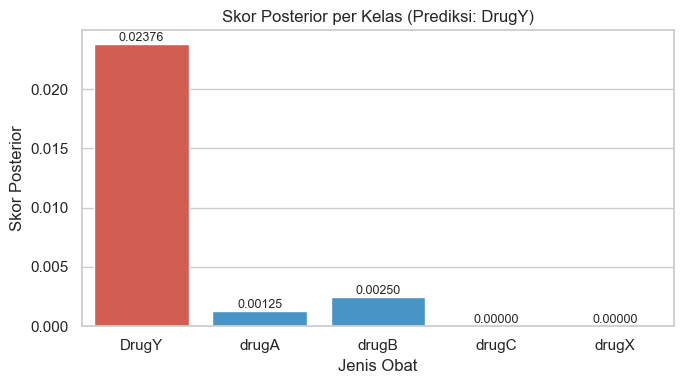

In [19]:
plt.figure(figsize=(7, 4))
warna = ["#e74c3c" if k == hasil else "#3498db" for k in skor_posterior.index]
sns.barplot(x=skor_posterior.index, y=skor_posterior.values,
            hue=skor_posterior.index, palette=warna, legend=False)
plt.title(f"Skor Posterior per Kelas (Prediksi: {hasil})")
plt.xlabel("Jenis Obat")
plt.ylabel("Skor Posterior")
for i, v in enumerate(skor_posterior.values):
    plt.text(i, v, f"{v:.5f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 11. Kesimpulan — Fitur Paling Berpengaruh
Salah satu cara sederhana untuk melihat fitur mana yang paling berpengaruh terhadap
penentuan jenis obat adalah dengan membandingkan **akurasi model saat hanya
mengandalkan satu fitur** (dihitung pada bagian 5–8). Semakin tinggi akurasinya,
semakin besar pengaruh fitur tersebut terhadap Drug.

In [20]:
ringkasan_akurasi = pd.Series({
    "Age": akurasi_age,
    "BP": akurasi_bp,
    "Cholesterol": akurasi_chol,
    "Na_to_K": akurasi_natok,
}).sort_values(ascending=False)

print("Akurasi model per fitur (semakin tinggi = semakin berpengaruh):")
print(ringkasan_akurasi.to_string(float_format=lambda x: f"{x:.2f}%"))

fitur_paling_berpengaruh = ringkasan_akurasi.idxmax()
print(f"\n>>> Fitur paling berpengaruh terhadap jenis obat: {fitur_paling_berpengaruh}")

Akurasi model per fitur (semakin tinggi = semakin berpengaruh):
Na_to_K       54.50%
BP            52.00%
Age           45.50%
Cholesterol   45.50%

>>> Fitur paling berpengaruh terhadap jenis obat: Na_to_K


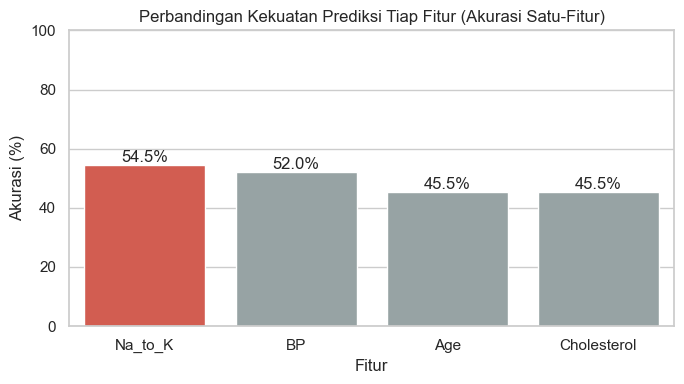

In [21]:
plt.figure(figsize=(7, 4))
warna = ["#e74c3c" if f == fitur_paling_berpengaruh else "#95a5a6" for f in ringkasan_akurasi.index]
sns.barplot(x=ringkasan_akurasi.index, y=ringkasan_akurasi.values,
            hue=ringkasan_akurasi.index, palette=warna, legend=False)
plt.title("Perbandingan Kekuatan Prediksi Tiap Fitur (Akurasi Satu-Fitur)")
plt.xlabel("Fitur")
plt.ylabel("Akurasi (%)")
for i, v in enumerate(ringkasan_akurasi.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Ringkasan akhir:**
- Prior menunjukkan `DrugY` dan `drugX` adalah kelas paling umum di data (sebelum melihat fitur apapun).
- Dari bagian 5–8, fitur **`Na_to_K`** dan **`BP`** biasanya paling diskriminatif karena punya
  pola likelihood yang tajam per kelas (banyak nilai 1.0 atau 0.0 di tabel likelihood-nya),
  sedangkan `Age` cenderung tersebar merata di semua kelas sehingga kurang informatif sendirian.
- Fitur dengan **akurasi satu-fitur tertinggi** pada bagian 11 dapat dianggap sebagai fitur
  yang paling menentukan jenis obat, meski keputusan akhir tetap menggabungkan **semua fitur**
  lewat rumus posterior (bagian 10) untuk hasil yang paling akurat.

Coba ubah `pasien_baru` di bagian 9 untuk menguji kasus lain! 🎯